In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings('ignore')

# 0. Загрузка данных

Объединим данные из обеих таблиц: left join по `TransactionID` (identity-информация есть только у ~25% транзакций).

In [2]:
df_transaction = pd.read_csv('../data/train_transaction.csv')
df_identity = pd.read_csv('../data/train_identity.csv')
df = df_transaction.merge(df_identity, on='TransactionID', how='left', indicator=True)

df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,_merge
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


## Признак `has_identity`

**Гипотеза-возражение:** флаг избыточен — CatBoost восстановит его из паттернов
пропусков в identity-колонках (режим `nan_mode='Min'` позволяет сплиту изолировать NaN).

**Разбор.** Пропуск в конкретной колонке — свойство колонки, а `has_identity` —
индикатор *джойна*. Внутри «опознанных» транзакций отдельные поля тоже часто пусты,
поэтому `isnan(id_XX)` — шумный прокси. Проверка показала: `id_01` заполнен в 100%
identity-строк, т.е. флаг технически восстановим из одной колонки.

**Решение: флаг оставляем.** Главный аргумент — интерпретируемость: в feature
importance / SHAP «отсутствие идентификации» виден как отдельный именованный фактор,
а не размазан по 40 isnan-паттернам. Цена — один булев столбец.

In [3]:
df['hasIdentity'] = (df['_merge'] == 'both').astype(int)
df.drop(columns=['_merge'], inplace=True)
print(df['hasIdentity'].mean().round(4), '— доля транзакций с identity')

0.2442 — доля транзакций с identity


In [4]:
if (df['id_01'].notna() == df['hasIdentity'].astype(bool)).all():
    print('id_01 заполнен во всех identity-строках')
else:
    print('id_01 заполнен НЕ во всех identity-строках')

id_01 заполнен во всех identity-строках


In [5]:
print(df.groupby('hasIdentity')['isFraud'].mean().round(4))

hasIdentity
0    0.0209
1    0.0785
Name: isFraud, dtype: float64


# 1. TransactionAmt

## 1.1. Логарифмирование

В baseline входят сырое значение и `TransactionAmtLog`, где:

$TransactionAmtLog = log1p(TransactionAmt) = log(1 + TransactionAmt)$

Обоснование:
1. Денежные величины скошены вправо; лог переводит шкалу в мультипликативную (важна кратность суммы, а не абсолютная дельта).
2. Логарифм не расширяет класс достижимых разбиений признака (в силу инвариантности деревьев к монотонным преобразованиям), однако измененнная геометрия признака потенциально полезна при построении производных агрегатов, так как позволяет нативно сравнивать не абсолютные, а относительные разности сумм.
3. `log1p` vs `log`: на train нулевых сумм нет, но выбран `log1p` как конвенция — численно корректен при нулях, которые в реальном эквайринге не только возможны, но и потенциально характерны для фрода (например, верификационные авторизации на $0.00 при проверке краденых карт). Обеспечивает переносимость пайплайна за пределы выборки.

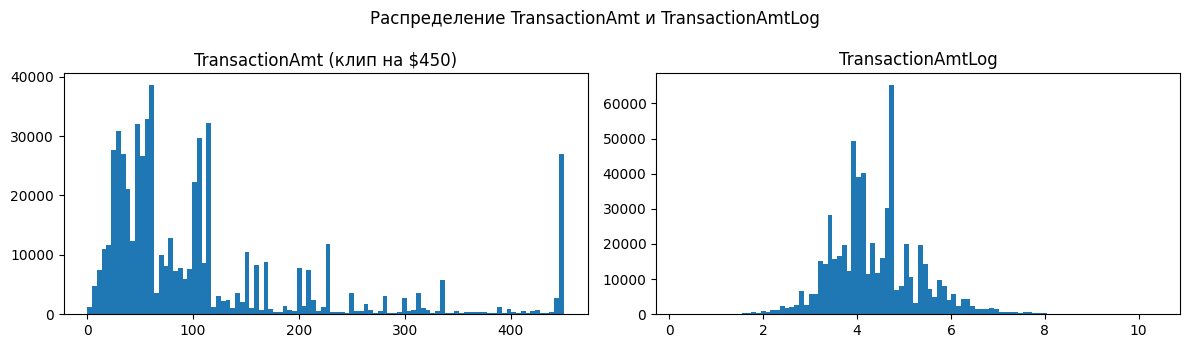

In [6]:
df['TransactionAmtLog'] = np.log1p(df['TransactionAmt'])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(df['TransactionAmt'].clip(upper=450), bins=100)

ax[0].set_title('TransactionAmt (клип на $450)')
ax[1].hist(df['TransactionAmtLog'], bins=100)
ax[1].set_title('TransactionAmtLog')
plt.suptitle('Распределение TransactionAmt и TransactionAmtLog')
plt.tight_layout(); plt.show()

## 1.2. TransactionNDecimal

**Гипотеза: «количество значащих десятичных знаков информативно».**

In [7]:
df['TransactionNDecimal'] = df['TransactionAmt'].apply(
    lambda x: len(str(x).split('.')[1].rstrip('0')) if '.' in str(x) else 0)

print(
    df.groupby(
        df['TransactionNDecimal'].clip(upper=3)
    )['isFraud'].agg(['mean', 'count']).round(4)
)

                       mean   count
TransactionNDecimal                
0                    0.0357  305013
1                    0.0187   22937
2                    0.0104  200657
3                    0.1172   61933


Группа 3+ знаков — ×3.3 к базовому уровню фрода.

Интерпретация: суммы с 3+ знаками — следы конвертации валюты, т.е. признак детектирует «сумма не представима как целые центы» $\approx$ зарубежное происхождение транзакции.

Группа с 2 знаками, напротив, втрое безопаснее базового уровня — признак различает в обе стороны.

**Вывод: `TransactionNDecimal` включается в baseline.** Дерево не восстановит этот сигнал из сырого Amt самостоятельно: число знаков не монотонно по сумме (у \$50.00 и \$50.985 близкие значения, но разные группы), сплитами по Amt оно не выражается.

## 1.3. Отклоненная гипотеза

**Проверяемая гипотеза: «легитимные транзакции чаще имеют круглые суммы».**

In [8]:
df['TransactionCents'] = ((df['TransactionAmt'] * 100).round() % 100).astype(int)
print(df.groupby('isFraud')['TransactionCents'].apply(lambda s: (s == 0).mean()).round(4))

isFraud
0    0.5171
1    0.5304
Name: TransactionCents, dtype: float64


Результат проверки: доля `TransactionCents == 0` — 51.7% (не-фрод) vs 53.0% (фрод).

Разница 1.3 п.п. — размер эффекта пренебрежим. Гипотеза не подтвердилась.

In [9]:
df.drop(columns=['TransactionCents'], inplace=True)

# 2. Время: TransactionDT

`TransactionDT` — время в секундах от неизвестной референсной даты T0 (минимум = 86400, т.е. первая транзакция ровно через сутки от T0).

Абсолютная привязка T0 к конкретной дате неизвестна и не нужна: периодические компоненты извлекаются арифметикой остатков, а сдвиг шкалы — монотонная перестановка меток, дерево выучит паттерн в любой системе отсчёта.

Решения:
- `TransactionHour` (0–23) — добавляем в baseline, как числовой и как категориальный
- `TransactionDoW` (0–6) — добавляем в baseline, категориальный
- `TransactionDay` — не используем как признак (сырой тренд времени: test целиком позже train). Служебная колонка для валидационных
  сплитов и оконного построения фильтров на следующих этапах
- `TransactionDT` — не используем как признак, аналогично

Оговорка для интерпретации: транзакции из разных часовых поясов, `hour` — смесь
локальных времён, поэтому суточный провал размыт.

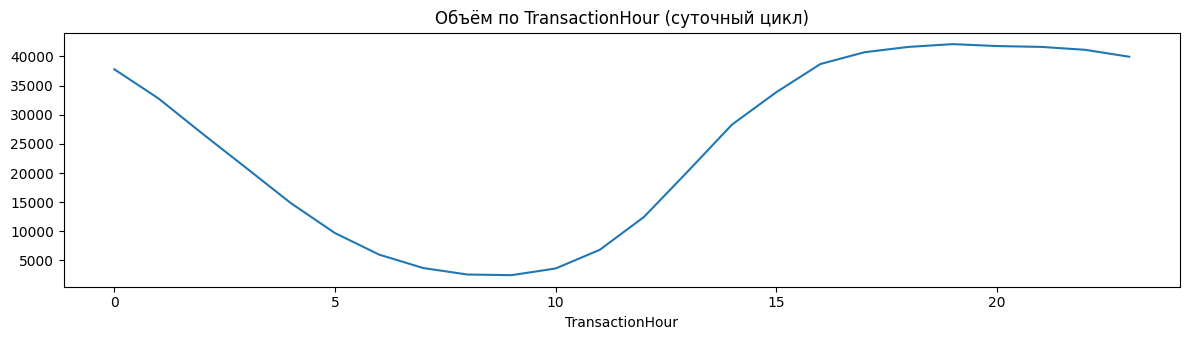

In [10]:
df['TransactionHour'] = (df['TransactionDT'] // 3600) % 24
df['TransactionDay'] = df['TransactionDT'] // 86400           
df['TransactionDoW'] = (df['TransactionDay'] % 7).astype(int)

df.groupby('TransactionHour').size().plot(figsize=(12, 3.5), title='Объём по TransactionHour (суточный цикл)')
plt.tight_layout(); plt.show()

**Замечание: D9 = TransactionHour / 24**

Организаторы сами добавили суточную компоненту в D-признаки: колонка D9 — это час суток, делённый на 24. Подтверждает, что суточный цикл информативен по мнению авторов данных. При этом `D9` содержит ~87% пропусков.

Вывод: отказ от `D9` в пользу `TransactionHour`.

In [11]:
m = df['D9'].notna()
assert np.allclose(df.loc[m, 'D9'], df.loc[m, 'TransactionHour'] / 24, atol=1e-6), 'D9 != TransactionHour/24 — проверить'
print('D9 == TransactionHour/24 на всех непустых строках — подтверждено')
print(f'Доля пропусков D9: {df["D9"].isna().mean():.2f}')

D9 == TransactionHour/24 на всех непустых строках — подтверждено
Доля пропусков D9: 0.87


# 3. D-признаки: два типа дельт и нормализация

D1–D15 — временные дельты. Семейство неоднородно, и это определяет обработку:

- **Тип А (гэп):** «количество дней от предыдущей транзакции до текущей» — разность двух скользящих событий; распределение примерно стационарно, дрейфа нет.
- **Тип Б (якорь):** «количество дней с фиксированного события X» (выпуск / первое появление карты и т.д.). Для конкретной сущности растёт линейно с календарём: $D = t − t_X$. Подвержен дрейфу: test на полгода позже train $\Rightarrow$ вся масса значений сдвинута вверх $\Rightarrow$ модель встречает диапазоны, которых не видела.

Решение проблемы дрейфа для типа Б - **нормализация**:

$Dn = D − TransactionDT / 86400 \approx (t − t_X) - t = -t_X$

- Для типа Б: нормализация превращает признак в **константу сущности** ('минус дата фиксированного события X'). Таким образом, все, что модель выучила на train-значениях, останется валидным в test.
- Для типа А: нормализация наоборот создаёт дрейф ($Dn = D − TransactionDT / 86400 \approx (t_2 − t_1) - t_2 = -t_1$, где $t_1$ - сырое время некоторого скользящего события. Вывод: нормализовать гэпы нельзя.

In [12]:
d_cols = [f'D{i}' for i in range(1, 16)]
for c in d_cols:
    df[c + 'Norm'] = df[c] - df['TransactionDay']

In [13]:
d1 = df.dropna(subset=['D1'])
card_stats = (d1.groupby('card1')
                .agg(n=('TransactionID', 'size'),
                     span=('TransactionDay', lambda s: s.max() - s.min()),
                     nuniq=('D1Norm', lambda s: s.round().nunique()))
                .query('n >= 50 and span >= 120 and 2 <= nuniq <= 5')
                .sort_values('n', ascending=False))
cards = card_stats.head(3).index.tolist()

d3 = df.dropna(subset=['D3'])

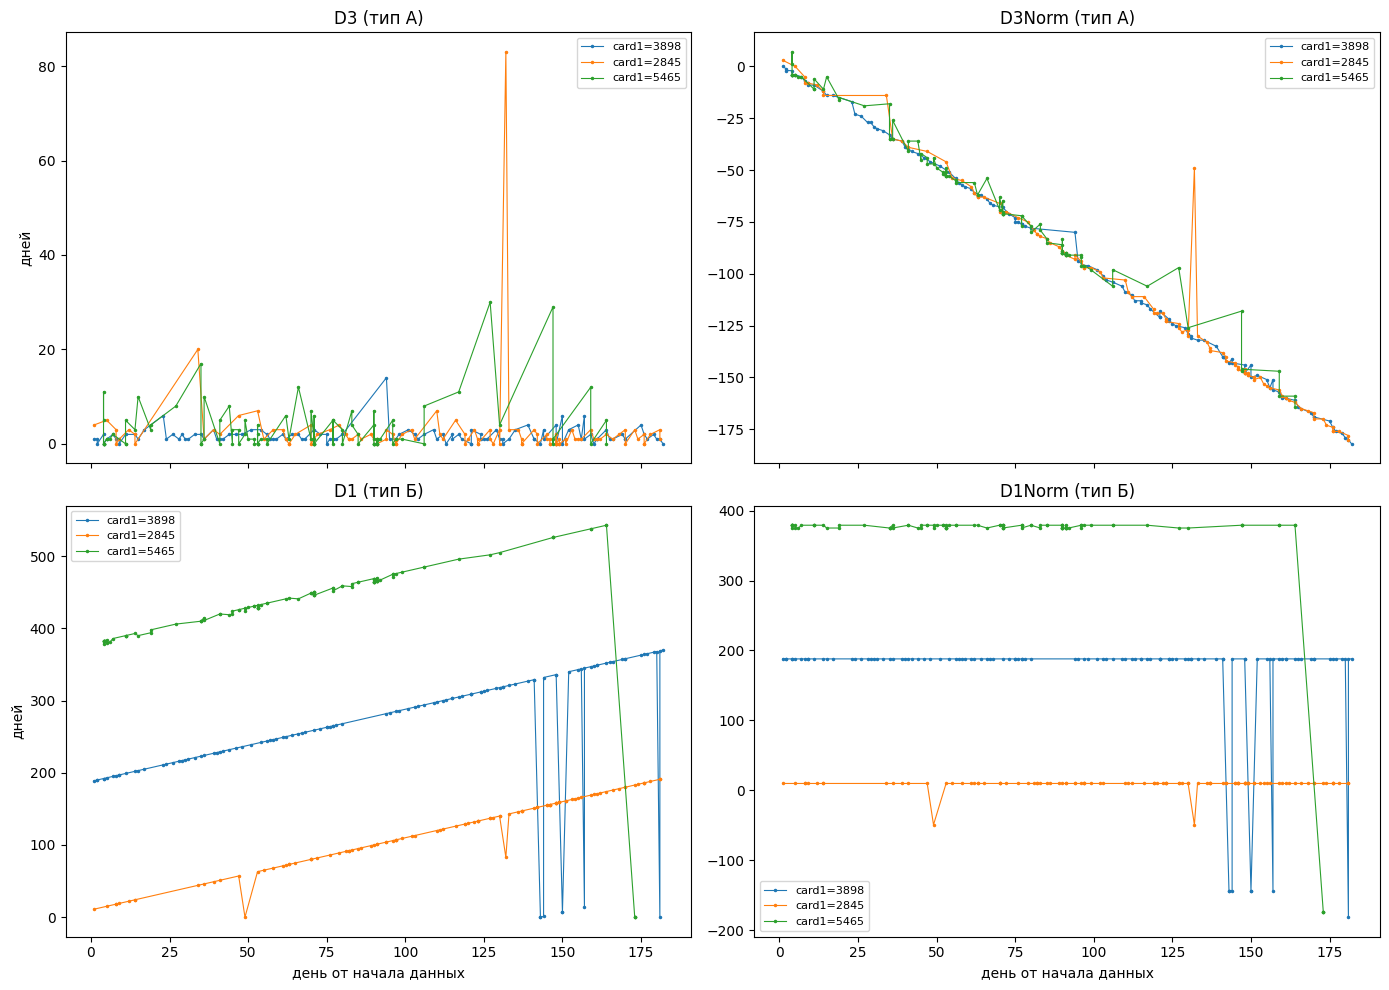

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for c in cards:
    g1 = d1[d1['card1'] == c].sort_values('TransactionDay')
    g3 = d3[d3['card1'] == c].sort_values('TransactionDay')
    axes[0, 0].plot(g3['TransactionDay'], g3['D3'],  marker='.', ms=3, lw=0.8, label=f'card1={c}')
    axes[0, 1].plot(g3['TransactionDay'], g3['D3Norm'], marker='.', ms=3, lw=0.8, label=f'card1={c}')
    axes[1, 0].plot(g1['TransactionDay'], g1['D1'],  marker='.', ms=3, lw=0.8, label=f'card1={c}')
    axes[1, 1].plot(g1['TransactionDay'], g1['D1Norm'], marker='.', ms=3, lw=0.8, label=f'card1={c}')
        

axes[0, 0].set_ylabel('дней')
axes[1, 0].set_ylabel('дней')
axes[1, 0].set_xlabel('день от начала данных')
axes[1, 1].set_xlabel('день от начала данных')
for axis1 in axes:
    for axis2 in axis1:
        axis2.legend(fontsize=8)
axes[0, 0].set_title('D3 (тип А)')
axes[0, 1].set_title('D3Norm (тип А)')
axes[1, 0].set_title('D1 (тип Б)')
axes[1, 1].set_title('D1Norm (тип Б)')
plt.tight_layout(); plt.show()

### Интерпретация графика

Одна и та же операция нормализации действует на два типа противоположно:
- **Верхний ряд, D3 (тип А, гэп).** Сырой D3 — стационарный шум: длительности инвариантны к сдвигу календаря, у сущности они не растут со временем. После нормализации — нисходящая линия с наклоном ≈ −1 день/день: $D3Norm = -$(дата предыдущей транзакции), а она у живой сущности движется вперёд вместе с календарём. Нормализация ломает признак.

- **Нижний ряд, D1 (тип Б, якорь).** Сырой D1 — пучок восходящих «лесенок» (+1 день/день): возраст сущности растёт с календарём, наследуя нестационарность самого окна наблюдения, — именно этот рост уводит test-значения за пределы train-диапазона. После нормализации — горизонтальные «полки»: $D1Norm = -$(дата первого появления), константа сущности. Нормализация чинит признак: всё, что модель выучила о train-значениях, остаётся валидным в test.

### Дополнительное наблюдение

На нижнем правом графике видно, что `card_i` — не одна карта, а группа (BIN-подобный идентификатор): каждая линия распадается на несколько параллельных 'полок' — по одной на реальную карту внутри группы. Таким образом, `D1Norm` расслаивает `card_i` на отдельные сущности — прямая мотивация композитного ключа `card1 + addr1 + D1Norm` (≈ конкретная карта конкретного клиента) как элемента будущих фильтров Блума: «видели ли эту карту раньше», «замечена ли во фроде» и т.д.

### Отбор D-признаков: adversarial validation

Отбор версий признаков автоматизируется через adversarial validation: для каждой D-колонки однопризнаковый классификатор train-vs-test прогоняется на обеих версиях — сырой и нормализованной; в модель идёт версия с AUC, близким к 0.5, если дрейфуют обе — колонка исключается. Отдать все версии в CatBoost «на самоотбор» нельзя: жадный выбор сплитов оценивает признаки по лоссу на train, где дрейф не виден по определению, а нормализованный гэп — по сути просто сырое время, корреляционно связанное с таргетом и потому охотно используемое моделью во вред test-предсказаниям. AV же измеряет именно сдвиг распределения, не размечая колонки на «тип А / тип Б» вручную (типы остаются интерпретацией результата); критерий воспроизводим.


### Результат AV (постфактум)

Прогон adversarial validation (`reports/av_d_features.csv`) опроверг ожидание по EDA:
**ни одна `Norm`-версия не прошла порог**, в модель идут сырые D1, D2, D3, D7, D8, D12;
остальные исключены (дрейф обеих версий). Joint AUC train-vs-test по D-блоку:
0.776 → 0.588 после отбора.

# 4. V-признаки: решение о редукции

Свойства семейства (детали — 01_eda, §1.14):

* сильная внутренняя избыточность;
* блочные пропуски: колонки распадаются на ~15 групп, где вся группа заполнена или пуста одновременно — отпечаток генерации;
* индивидуально слабые, коллективно заметные.

**Рассматривалась** дедупликация по NaN-группам: группировка колонок по маске пропусков, внутри группы — жадное склеивание при $|\rho| > 0.98$ (Пирсон) с представителем по максимальному `nunique`. Прогон показал: удаляется лишь **38 колонок из 339**. Причина слабого эффекта — V-признаки квантованы и обрезаны: почти-дубликаты совпадают по рангам, но не линейно, и Пирсон на пороге 0.98 их не склеивает.

**Решение: редукция отклонена, все 339 V-признаков подаются в модель как есть.** Выигрыш от −11% колонок — единицы процентов времени обучения; держать ради этого отдельную процедуру с параметром, файлом-артефактом и задачей верификации — плохой размен.

# 5. Категориальные признаки: производные

Сырые категориальные колонки (card1–card6, addr1/2, ProductCD, P/R_emaildomain, M1–M9, DeviceType, DeviceInfo, id_12–id_38) идут в CatBoost нативно, без кодирования — решений тут нет. Решения есть о **производных** признаках: EDA (01_eda) дала три наблюдения, каждое мотивирует свое укрупнение. Общее свойство всех трех преобразований: это словарные мапинги без обучения на данных — утечки нет, а новые значения в test (свежие версии браузеров, новые модели устройств) попадают в уже знакомые модели семейства.

## 5.1. Email-домены → суффикс и группа провайдера

Наблюдения из 01_eda, §1.9:
1. один провайдер представлен множеством вариантов написания (gmail.com / yahoo.co.jp / yahoo.es / ...);
2. региональные варианты массовых доменов заметно фродовее базовых (outlook.es — 13.0% против outlook.com — 9.5%);
3. редкие privacy-домены имеют кратный риск на крошечных выборках (protonmail.com — 40.8% на 76 транзакциях).

Признаки: `EmailSuffix` (все после первой точки: com / es / co.jp — несет «региональность») и `EmailProviderGroup` (нормализация к провайдеру). Сырые колонки остаются: для редких доменов вроде protonmail группа не увеличивает выборку (он сам себе группа), и точечный сигнал модель добирает из сырой категории.

In [15]:
def email_suffix(domain):
    if pd.isna(domain):
        return 'missing'
    parts = domain.split('.', 1)
    return parts[1] if len(parts) > 1 else 'none'

PROVIDER_GROUPS = {
    'gmail': 'google', 'googlemail': 'google',
    'hotmail': 'microsoft', 'outlook': 'microsoft', 'live': 'microsoft', 'msn': 'microsoft',
    'yahoo': 'yahoo', 'ymail': 'yahoo', 'rocketmail': 'yahoo',
    'icloud': 'apple', 'me': 'apple', 'mac': 'apple',
    'aol': 'aol', 'aim': 'aol',
}

def email_provider_group(domain):
    if pd.isna(domain):
        return 'missing'
    provider = domain.split('.')[0].lower()
    return PROVIDER_GROUPS.get(provider, provider)

for col in ['P_emaildomain', 'R_emaildomain']:
    prefix = col.split('_')[0]
    df[prefix + '_EmailSuffix'] = df[col].apply(email_suffix)
    df[prefix + '_EmailProviderGroup'] = df[col].apply(email_provider_group)

df['P_EmailProviderGroup'].value_counts().head(10)

P_EmailProviderGroup
google       228851
yahoo        105969
missing       94456
microsoft     59477
anonymous     36998
aol           28604
apple          8225
comcast        7888
att            4033
sbcglobal      2970
Name: count, dtype: int64

## 5.2. DeviceInfo → семейство устройства

Сырой `DeviceInfo` смешивает уровни: от «Windows» до конкретных моделей («SM-G930F»). Модели дробят категорию на тысячи редких значений, причем в test появляются новые модели, которых нет в train. Признак `DeviceFamily` — укрупнение до производителя/платформы по префиксам и подстрокам; сырая колонка остается.

In [16]:
DEVICE_RULES = [
    ('windows', 'windows'), ('ios device', 'ios'), ('macos', 'macos'),
    ('sm-', 'samsung'), ('sm ', 'samsung'), ('samsung', 'samsung'), ('gt-', 'samsung'),
    ('moto', 'motorola'), ('xt1', 'motorola'),
    ('huawei', 'huawei'), ('ale-', 'huawei'), ('hi6', 'huawei'),
    ('lg-', 'lg'),
    ('rv:', 'firefox_ua'), ('trident', 'ie'),
    ('pixel', 'google'), ('nexus', 'google'),
    ('htc', 'htc'), ('asus', 'asus'), ('lenovo', 'lenovo'),
    ('linux', 'linux'),
]

def device_family(info):
    if pd.isna(info):
        return 'missing'
    low = str(info).lower()
    for pat, fam in DEVICE_RULES:
        if pat in low:
            return fam
    return 'other'

df['DeviceFamily'] = df['DeviceInfo'].apply(device_family)
df['DeviceFamily'].value_counts()

DeviceFamily
missing       471874
windows        47775
ios            19782
macos          12573
samsung        12091
ie              7440
other           4971
firefox_ua      4385
motorola        3502
huawei          2605
lg              2331
htc              406
google           320
lenovo           318
linux            121
asus              46
Name: count, dtype: int64

## 5.3. id_31 → семейство браузера

Наблюдение из 01_eda, §2.2: значения версионированы (chrome 63.0, chrome 69.0, ...) — сырая колонка дробит один браузер на десятки категорий, и со временем появляются версии, которых нет в train. Признак `BrowserFamily` — имя без версии.

In [17]:
def browser_family(val):
    if pd.isna(val):
        return 'missing'
    return re.sub(r'[\d\.]+', '', str(val)).strip() or 'other'

df['BrowserFamily'] = df['id_31'].apply(browser_family)
df['BrowserFamily'].value_counts().head(10)

BrowserFamily
missing                  450258
chrome                    49855
chrome  for android       19701
mobile safari             16797
mobile safari generic     11474
ie  for desktop            9030
safari generic             8195
firefox                    6901
edge                       6401
chrome generic             4778
Name: count, dtype: int64

**Решение: производные `EmailSuffix`, `EmailProviderGroup` (для P и R), `DeviceFamily`, `BrowserFamily` включаются в baseline** как категориальные; сырые колонки-источники остаются.

# 6. Схема валидации

Train покрывает ~6 месяцев, test — следующие ~6. Следствия:

1. **Временной holdout** (последние ~20% train по времени): быстрый цикл отладки и выбор числа итераций через early stopping.
2. **Случайный KFold не подходит:** завышает оценку из-за временного дрейфа и попадания транзакций одного клиента в train и valid одновременно.
3. **Скользящий временной CV** - основная метрика сравнения экспериментов: 3 сплита «обучение на блоках 0..k, валидация на k+1».
4. Сабмит: переобучение на всём train (итерации из early stopping $* k$, где $k \approx 1.1–1.2$), public/private LB как внешняя проверка валидации.
5. CatBoost: `has_time=True` + сортировка по `TransactionDT` — ordered target statistics для категориальных считаются только по прошлому (анти-утечка на уровне модели).

In [18]:
assert (df['TransactionDT'].diff()[1:] >= 0).all(), 'Транзакции должны быть отсортированы по времени'
print('Транзакции отсортированы по времени')

Транзакции отсортированы по времени


In [19]:
# основной holdout
split_day = df['TransactionDay'].quantile(0.8)
train_idx = df.index[df['TransactionDay'] < split_day]
valid_idx = df.index[df['TransactionDay'] >= split_day]
print(
    "holdout:",
    f"  train={len(train_idx)}",
    f"  valid={len(valid_idx)}",
    f"  граница — день {int(split_day)}",
    sep="\n"
)

holdout:
  train=472006
  valid=118534
  граница — день 141


In [20]:
df['MonthBlock'] = (df['TransactionDay'] // 30).astype(int)
blocks = sorted(df['MonthBlock'].unique())
folds = [
    (df.index[df['MonthBlock'] <= b], df.index[df['MonthBlock'] == b + 1])
    for b in blocks[3:-1]
]
for i, (train_i, val_i) in enumerate(folds):
    print(f'fold {i}: train до блока {df.loc[train_i, "MonthBlock"].max()}, '
          f'val блок {df.loc[val_i, "MonthBlock"].max()}, '
          f'{len(train_i)} / {len(val_i)}')

fold 0: train до блока 3, val блок 4, 410601 / 85303
fold 1: train до блока 4, val блок 5, 495904 / 86525
fold 2: train до блока 5, val блок 6, 582429 / 8111


### Корректировка структуры фолдов

Предложенный вариант (`blocks[3:-1]`) дает вырожденный последний фолд: train покрывает
неполное число блоков, поэтому последний блок оказывается коротким огрызком — его
валидационная выборка почти на порядок меньше, чем у остальных фолдов.

**Почему это критично.** CV-среднее — основная метрика сравнения экспериментов
(baseline / bloom / exact). Оценка на выборке в несколько тысяч строк имеет заметно большую дисперсию, чем на полноценных фолдах: она вносит шум в среднее и раздувает разброс, на фоне которого
может затеряться эффект от добавления агрегационных признаков.

**Решение:** неполный последний блок отбрасывается, старт фолдов сдвигается на один
блок раньше (`blocks[2:-2]`) — так сохраняются три полноценных фолда сопоставимого
размера:

| фолд | train | valid |
|---|---|---|
| 0 | блоки 0–2 | блок 3 |
| 1 | блоки 0–3 | блок 4 |
| 2 | блоки 0–4 | блок 5 |

In [21]:
folds = [
    (df.index[df['MonthBlock'] <= b], df.index[df['MonthBlock'] == b + 1])
    for b in blocks[2:-2]
]
for i, (train_i, val_i) in enumerate(folds):
    print(f'fold {i}: train до блока {df.loc[train_i, "MonthBlock"].max()}, '
          f'val блок {df.loc[val_i, "MonthBlock"].max()}, '
          f'{len(train_i)} / {len(val_i)}')

fold 0: train до блока 2, val блок 3, 312574 / 98027
fold 1: train до блока 3, val блок 4, 410601 / 85303
fold 2: train до блока 4, val блок 5, 495904 / 86525


В конфиге: `drop_incomplete_last_block: true`, `cv_skip_first_blocks: 2`, `min_valid_rows: 30000`.

# 7. Сводка решений и бэклог для Claude Code

### Состав признаков baseline

| Группа | Решение |
|---|---|
| TransactionAmt | сырое + `TransactionAmtLog`; `TransactionNDecimal` — **включён** (fraud rate ×3.3 в группе 3+ знаков, различает в обе стороны; дерево не восстановит из сырого Amt — см. §1.2); `TransactionCents` — отклонён (§1.3) |
| Время | `TransactionHour` (числовой) + `TransactionHourCat` (категориальный), `TransactionDoW` (кат.); `TransactionDay`, сырой `TransactionDT` — только служебно |
| D-признаки | для каждой колонки версия (сырая / `Norm`) выбирается adversarial validation: в модель идёт версия с AUC train-vs-test ≈ 0.5, при дрейфе обеих — исключение; ожидание по EDA — `Norm` для D1, D4, D10, D11, D15, сырые для остальных; D9 — выброшен (дубликат `TransactionHour`); фактическая резолюция - в configs/base.yaml (блок d_features) |
| C1–C14 | как есть, во всех экспериментах одинаково (предпосчитаны организатором) |
| id_01–id_11 | как есть: анонимизированные числовые рейтинги/счетчики, предпосчитаны организатором — аналогично C1–C14; пропуски обрабатывает CatBoost |
| dist1/2 | как есть: вариантивные признаки расстояния; пропуски обрабатывает CatBoost |
| V-признаки | все 339 как есть; редукция рассмотрена и отклонена (§4) |
| Категориальные | card1–6, addr1/2, ProductCD, P/R_emaildomain, M1–M9, DeviceType, DeviceInfo, id_12–id_38 — нативно в CatBoost; производные `P_EmailSuffix`, `R_EmailSuffix`, `P_EmailProviderGroup`, `R_EmailProviderGroup`, `DeviceFamily`, `BrowserFamily` — включены (§5) |
| Флаги | `hasIdentity` |
| Запрещено в baseline | membership / frequency / «seen before» / агрегаты по сущностям — это исследуемый эффект этапов 2–3 |

### Правила экспериментов
- Изменение состава базовых признаков — только во всех экспериментах одновременно, с пересчётом.
- Гиперпараметры фиксируются после одного лёгкого тюнинга и одинаковы во всех экспериментах.
- Старт: depth=8, lr=0.05, iterations=5000, early_stopping=200, eval_metric=AUC,
  has_time=True, фиксированный seed.
- Методика сравнения экспериментов: фолды соответствуют разным временным периодам
  и различаются по сложности, поэтому эксперименты сравниваются попарно по фолдам:
  $\Delta_{fold} = AUC_{эксперимент}(fold) - AUC_{baseline}(fold)$ (парное сравнение
  вычитает сложность периода и позволяет детектировать эффект, меньший, чем разброс
  между фолдами).

### Бэклог задач для Claude Code

Препроцессинг разделён на два слоя: **слой 1** строит все признаки-кандидаты и не
зависит ни от каких резолюций; **слой 2** собирает из кандидатов матрицу конкретного
эксперимента по конфигу (резолюция D, вычет `forbidden_as_features`, `extra_features` эксперимента).
AV — потребитель слоя 1 и поставщик резолюции для слоя 2.

1. **Слой 1: построение признаков-кандидатов + модуль AV.** Merge таблиц, служебные
   колонки, признаки §0–§5 этого ноутбука, **обе версии всех D-колонок** (сырая и
   `Norm`). Поверх кандидатов — adversarial validation: однопризнаковый классификатор
   train-vs-test для каждой версии каждой D-колонки; таблица AUC →
   `reports/av_d_features.csv` (пойдёт в приложение диплома). Плюс суммарная
   различимость train/test по D-блоку до/после отбора (замыкает доказательство).
   Ожидание по EDA как санити-проверка результата: `Norm` для D1, D4, D10, D11, D15,
   сырые для остальных. *Выход задачи: таблица AV; резолюцию в `configs/base.yaml`
   (блок `d_features`, снять `status: pending_av`) вписывает пользователь.*

2. **Слой 2 + пайплайн baseline.** Селекция признаков по конфигу (правило: в модель —
   версия с AUC ≤ порога из `adversarial_validation.auc_pass_threshold`, при дрейфе
   обеих версий колонка исключена) → CatBoost → holdout + скользящий CV →
   переобучение на всём train (итерации × `full_train_iterations_multiplier`) →
   сабмит (public/private LB). Строка результатов — в `reports/experiments.md`.

3. **Тесты на отсутствие утечки** (пишутся до пайплайна): ни одна колонка из
   `features.forbidden_as_features` не попадает в матрицу признаков; валидация строго
   позже обучения по времени; датасет отсортирован по `TransactionDT` при
   `has_time=True`.

4. **Фиксация время обучения / пиковая память** — точка отсчёта для раздела про
   эффективность BF.